**Task 1:**

Load cleaned_data.csv from Part 1.

Define:

Feature matrix X: all columns except the target.

Regression label y_reg: one continuous numeric column (e.g., price, income).

Classification label y_clf: a binary column derived by binarizing y_reg at its median (y_clf = (y_reg > y_reg.median()).astype(int)) or another natural binary column in the dataset.

In [2]:
# import essential libraries
import pandas as pd
import numpy as np

In [3]:
# load the cleaned dataset & print first 5 rows
df=pd.read_csv('cleaned_data.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Define Regression target variable

y_reg=df['price'] # predicting exact price is regression task

# Define classification target variable

y_clf=(df["price"] > df["price"].median()).astype(int) # here we define two categories prices below median "Cheap" (0) and above median "Expensive" (1)


In [5]:
# Define Feature Matrix
X = df.drop(columns=["price"]) # since price is the target variable this column is dropped and rest are retained

In [6]:
# check shapes
print("X Shape :", X.shape)
print("Regression Target :", y_reg.shape)
print("Classification Target :", y_clf.shape)

X Shape : (53794, 9)
Regression Target : (53794,)
Classification Target : (53794,)


X (feature matrix) has 53794 rows and 9 columns

Regression target variable has 53794 rows and 1 column

Classification target has 53794 rows and 1 column

**Note - A single column from the dataframe is called as Series**

**Task 2:**

Encode categorical columns: For each categorical column in X:

If the categories have a natural order (e.g., Low < Medium < High), apply label encoding by mapping categories to integers that preserve the order.

If the categories have no natural order (e.g., city names, color codes), apply one-hot encoding using pd.get_dummies() or sklearn.preprocessing.OneHotEncoder. Drop the first dummy column to avoid multicollinearity.



In [13]:
# we have 3 categorical columns in the dataset -> cut,color,clarity

# cut column has a natural order:
# Fair < Good < Very Good < Premium < Ideal hence  apply label encoding

cut_order = {
    "Fair": 0,
    "Good": 1,
    "Very Good": 2,
    "Premium": 3,
    "Ideal": 4
}

X["cut"] = X["cut"].map(cut_order)

# color and clarity do not have a natural order hence apply one-hot encoding

X = pd.get_dummies( # appying one-hot encoding using Pandas get_dummies function
    X,
    columns=["color", "clarity"],
    drop_first=True  # avoids multicollinearity by removing one dummy column from each category.
) # Multicollinearity is a problem in statistics especially in regression analysis that happens when your features (the independent factors) are too strongly related to each other.


In [15]:
# verify
print(X.head())
print() # adds extra space
print(X.shape)

   carat  cut  depth  table     x     y     z  color_E  color_F  color_G  \
0   0.23    4   61.5   55.0  3.95  3.98  2.43     True    False    False   
1   0.21    3   59.8   61.0  3.89  3.84  2.31     True    False    False   
2   0.23    1   56.9   65.0  4.05  4.07  2.31     True    False    False   
3   0.29    3   62.4   58.0  4.20  4.23  2.63    False    False    False   
4   0.31    1   63.3   58.0  4.34  4.35  2.75    False    False    False   

   color_H  color_I  color_J  clarity_IF  clarity_SI1  clarity_SI2  \
0    False    False    False       False        False         True   
1    False    False    False       False         True        False   
2    False    False    False       False        False        False   
3    False     True    False       False        False        False   
4    False    False     True       False        False         True   

   clarity_VS1  clarity_VS2  clarity_VVS1  clarity_VVS2  
0        False        False         False         False  
1     

**Task 3:**

Leak-free train-test split and scaling:

Split X and both labels into training and test sets using train_test_split(X, y, test_size=0.2, random_state=42).

Fit a StandardScaler only on the training features (scaler.fit(X_train)). Transform both X_train and X_test using this fitted scaler (scaler.transform(...)).


In [16]:
# import essential libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split for regression
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.2, # 80% training 20% testing
    random_state=42 # reproduceability
)

# split for classification
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.2, # 80% training 20% testing
    random_state=42 # # reproduceability
)

Although the feature matrix is the same, creating separate splits for regression and classification keeps the workflows independent and easier to follow.

In [17]:
# Standardize Regression Features

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Standardize Classification Features

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Verify shapes

print("Regression Train:", X_train_reg_scaled.shape)
print("Regression Test :", X_test_reg_scaled.shape)

print("Classification Train:", X_train_clf_scaled.shape)
print("Classification Test :", X_test_clf_scaled.shape)

Regression Train: (43035, 20)
Regression Test : (10759, 20)
Classification Train: (43035, 20)
Classification Test : (10759, 20)


**Task 4:**

Regression model — Linear Regression:

Train a LinearRegression model from sklearn.linear_model on the scaled training features and y_reg_train.

Predict on X_test_scaled to get y_pred_reg.

Compute and report: MSE using mean_squared_error(y_reg_test, y_pred_reg) and R² using r2_score(y_reg_test, y_pred_reg).

Print the model's coefficients alongside the corresponding feature names. Identify the three features with the largest absolute coefficient values.

Apply Ridge Regression (Ridge(alpha=1.0)) using the same split and scaling.



In [18]:
# import essential libraries
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg_scaled, y_reg_train)

# predict
y_pred_reg = linear_model.predict(X_test_reg_scaled)

# Evaluation metrics
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Linear Regression")
print("MSE :", mse)
print("R² :", r2)

Linear Regression
MSE : 1221432.9375377842
R² : 0.9198643675028599


In [19]:
# display coefficients
# coefficients represents feature importance
# It helps us to understand which features are contributing more towards prediction
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

print(coefficients)

         Feature  Coefficient
0          carat  5372.421118
1            cut   112.427508
2          depth  -107.790280
3          table   -59.879983
4              x -1130.863777
5              y    16.626070
6              z   -61.358037
7        color_E   -80.046093
8        color_F  -104.873400
9        color_G  -196.615501
10       color_H  -351.140025
11       color_I  -439.033961
12       color_J  -527.465309
13    clarity_IF   981.861739
14   clarity_SI1  1631.807302
15   clarity_SI2  1056.000776
16   clarity_VS1  1686.673129
17   clarity_VS2  1843.889740
18  clarity_VVS1  1285.879334
19  clarity_VVS2  1472.547312


In [20]:
# Three largest absolute coefficients
top3 = coefficients.copy()

top3["Absolute Coefficient"] = top3["Coefficient"].abs()

top3 = top3.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(top3.head(3))

        Feature  Coefficient  Absolute Coefficient
0         carat  5372.421118           5372.421118
17  clarity_VS2  1843.889740           1843.889740
16  clarity_VS1  1686.673129           1686.673129


In [21]:
# Apply Ridge Regression
# method used to reduce overfitting
# it shrinks the coefficients towards 0 but not exactly 0

ridge_model = Ridge(alpha=1.0) # degree of regularization. It controls how much the model is allowed to shrink the coefficients (the importance given to each feature).

ridge_model.fit(X_train_reg_scaled, y_reg_train)

# prediction
ridge_pred = ridge_model.predict(X_test_reg_scaled)

# evaluation metrics
ridge_mse = mean_squared_error(
    y_reg_test,
    ridge_pred
)

ridge_r2 = r2_score(
    y_reg_test,
    ridge_pred
)

print("Ridge Regression")
print("MSE :", ridge_mse)
print("R² :", ridge_r2)

Ridge Regression
MSE : 1221478.1724248927
R² : 0.919861399737559


In [22]:
# comparison table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R²": [r2, ridge_r2]
})

print(comparison)

               Model           MSE        R²
0  Linear Regression  1.221433e+06  0.919864
1   Ridge Regression  1.221478e+06  0.919861


**Task 5:**

Classification model — Logistic Regression:

Check y_clf_train.value_counts(). If one class has fewer than 35% of samples, address the imbalance using at minimum one of: (a) SMOTE from imblearn.over_sampling applied only to the training set, or (b) class_weight='balanced' in the logistic regression constructor.

Train a LogisticRegression from sklearn.linear_model on the (possibly resampled) training features and y_clf_train with max_iter=1000.
Predict class labels and probabilities on X_test_scaled.

Compute and report: confusion matrix using confusion_matrix(), accuracy, precision, recall, and F1 score using classification_report().
Compute and plot the ROC curve using roc_curve() from sklearn.metrics.

Calculate and report the AUC using roc_auc_score(). Plot the ROC curve with plt.plot(), add axis labels (False Positive Rate, True Positive Rate), a title, and annotate the AUC value on the plot.



In [23]:
# check class balance
print(y_clf_train.value_counts())
# calculate percentage
print(y_clf_train.value_counts(normalize=True) * 100)

price
0    21557
1    21478
Name: count, dtype: int64
price
0    50.091786
1    49.908214
Name: proportion, dtype: float64


both classes are balanced so no need to apply imbalnce techniques

In [24]:
# Train logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_clf_scaled,
    y_clf_train
)

# predict using probabilities

y_pred_clf = log_model.predict(
    X_test_clf_scaled
)

y_prob = log_model.predict_proba(
    X_test_clf_scaled
)[:,1] # This gives the probability that each sample belongs to Class 1.



In [25]:
# compute evaluation metrics

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print(confusion_matrix(
    y_clf_test,
    y_pred_clf
))

print(classification_report(
    y_clf_test,
    y_pred_clf
))

print("Accuracy:",
      accuracy_score(
          y_clf_test,
          y_pred_clf
      ))

[[5230  115]
 [ 133 5281]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5345
           1       0.98      0.98      0.98      5414

    accuracy                           0.98     10759
   macro avg       0.98      0.98      0.98     10759
weighted avg       0.98      0.98      0.98     10759

Accuracy: 0.9769495306255228


AUC : 0.9979257083202161


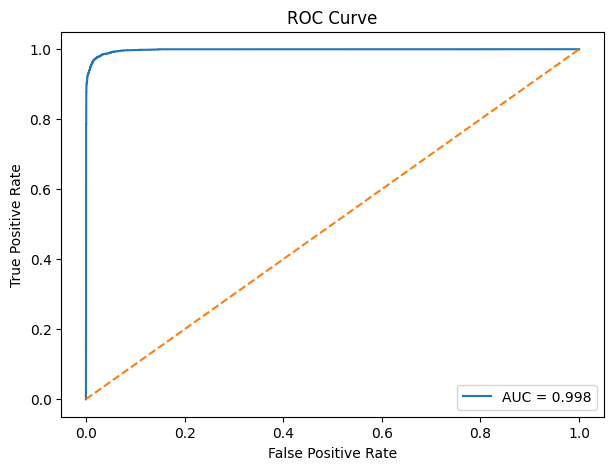

In [26]:
# ROC Curve

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_prob
)

auc = roc_auc_score(
    y_clf_test,
    y_prob
)

print("AUC :", auc)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Decision-threshold sensitivity:

 For the logistic regression model trained in Task 5 (with default threshold 0.5), generate predicted class probabilities on the test set using model.predict_proba(X_test_scaled)[:, 1].

 Vary the decision threshold from 0.30 to 0.70 in steps of 0.10. At each threshold, convert probabilities to class predictions using (proba >= threshold).astype(int) and compute precision, recall, and F1-score using precision_score(), recall_score(), and f1_score() from sklearn.metrics.

 Print all five rows as a table with columns: Threshold | Precision | Recall | F1.


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score
# evaluate at different thresholds

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_clf_test, y_pred)
    recall = recall_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred)

    results.append({
        "Threshold": threshold,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    })

threshold_table = pd.DataFrame(results)

print(threshold_table)

   Threshold  Precision  Recall      F1
0        0.3     0.9593  0.9874  0.9732
1        0.4     0.9703  0.9825  0.9763
2        0.5     0.9787  0.9754  0.9771
3        0.6     0.9851  0.9669  0.9760
4        0.7     0.9895  0.9538  0.9713


In [28]:
# Find the best threshold
best_threshold = threshold_table.loc[
    threshold_table["F1"].idxmax()
]

print("Best Threshold:")
print(best_threshold)

Best Threshold:
Threshold    0.5000
Precision    0.9787
Recall       0.9754
F1           0.9771
Name: 2, dtype: float64


**Task 6:**

Regularization experiment on Logistic Regression:

Train a second logistic regression with C=0.01 (strong regularization, i.e., stronger L2 penalty).

Compare its precision, recall, and AUC against the baseline C=1.0 model in a table.

In [29]:
# Train logistic regression with c=0.01

log_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000
)

log_model_c001.fit(
    X_train_clf_scaled,
    y_clf_train
)

# predict

y_pred_c001 = log_model_c001.predict(X_test_clf_scaled)

y_prob_c001 = log_model_c001.predict_proba(
    X_test_clf_scaled
)[:,1]

# Evaluation for the baseline model (C=1.0)

baseline_precision = precision_score(y_clf_test, y_pred_clf)
baseline_recall = recall_score(y_clf_test, y_pred_clf)
baseline_auc = roc_auc_score(y_clf_test, y_prob)

# Evaluation for the new model (C=0.01)

c001_precision = precision_score(y_clf_test, y_pred_c001)
c001_recall = recall_score(y_clf_test, y_pred_c001)
c001_auc = roc_auc_score(y_clf_test, y_prob_c001)

In [30]:
# comparison table

comparison = pd.DataFrame({
    "Model": ["C = 1.0", "C = 0.01"],
    "Precision": [baseline_precision, c001_precision],
    "Recall": [baseline_recall, c001_recall],
    "AUC": [baseline_auc, c001_auc]
})

print(comparison)

      Model  Precision    Recall       AUC
0   C = 1.0   0.978688  0.975434  0.997926
1  C = 0.01   0.976314  0.974511  0.997023


**Task 7:**

Bootstrap confidence interval for AUC difference. (Guided extension — full step-by-step instructions provided below; follow them in order.)

Quantify how reliably the C=1.0 logistic regression outperforms the C=0.01 model. Draw n=500 bootstrap samples from the test set: for each sample, use np.random.choice(len(y_clf_test), size=len(y_clf_test), replace=True) to sample row indices with replacement, index into y_clf_test and the predicted probabilities of both models, and compute the AUC difference (AUC of C=1.0 minus AUC of C=0.01) for that sample.

 After 500 iterations, compute the mean AUC difference and the 2.5th and 97.5th percentile of the 500 difference values using np.percentile.

 State whether the 95% confidence interval for the AUC difference excludes zero — if it does, the C=1.0 model's advantage is likely consistent across different data samples; if it includes zero, the difference may not be reliable.

In [31]:
# Bootstrap

np.random.seed(42)

auc_differences = []

n_bootstrap = 500

for i in range(n_bootstrap):

    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_true_boot = y_clf_test.iloc[indices]

    prob_c1 = y_prob[indices]
    prob_c001 = y_prob_c001[indices]

    auc_c1 = roc_auc_score(
        y_true_boot,
        prob_c1
    )

    auc_c001 = roc_auc_score(
        y_true_boot,
        prob_c001
    )

    auc_differences.append(
        auc_c1 - auc_c001
    )

In [32]:
# Confidence interval
mean_difference = np.mean(auc_differences)

lower = np.percentile(
    auc_differences,
    2.5
)

upper = np.percentile(
    auc_differences,
    97.5
)

print("Mean AUC Difference :", mean_difference)
print("95% Confidence Interval :")
print("Lower :", lower)
print("Upper :", upper)

Mean AUC Difference : 0.0009167613813226126
95% Confidence Interval :
Lower : 0.000570730252002738
Upper : 0.001329836666909806


In [33]:
# Check Whether CI Includes Zero
if lower > 0 or upper < 0:
    print("The 95% confidence interval excludes zero.")
else:
    print("The 95% confidence interval includes zero.")

The 95% confidence interval excludes zero.
